# TCC — Music Emotion Recognition (MER)
#### Autor: Augusto Jerke

---

## Objetivo

Este projeto compara três representações espectrais de áudio — **Mel Espectrograma**, **STFT** e **MFCC** — como entrada para redes neurais convolucionais (ResNet18) treinadas para reconhecer emoções em músicas.

O modelo prevê duas dimensões contínuas em escala [0, 1]:
- **Arousal**: nível de energia/excitação da música
- **Valence**: nível de positividade/negatividade emocional

O dataset utilizado é o **DEAM** (Database for Emotional Analysis of Music), com anotações dinâmicas frame a frame feitas por humanos via crowdsourcing.

### **Importação das bibliotecas**


In [2]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import glob
import torchaudio
import torchaudio.transforms as T
import torch
from dataset import DEAMDinamicoDataset, carregar_feature
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

### **Carregamento do Dataset**

In [3]:
dataset = pd.read_csv("data\\dynamic_annotations.csv")

### **Overview e Organização do Dataset**

O [DEAM (Database for Emotional Analysis of Music)](https://zenodo.org/record/1188976) é um benchmark público para reconhecimento de emoções em música, desenvolvido por Aljanaki et al. (2017) na Universidade de Utrecht.

**Características:**
- **1.802 músicas** licenciadas Creative Commons (faixas de 45s e música completa)
- **Anotações dinâmicas**: 1 frame a cada 500 ms, cobrindo do segundo 15 ao final de cada faixa (~72 frames por música)
- **Dimensões emocionais**: Arousal (energia/excitação) e Valence (positividade/negatividade)
- **Escala original**: [-1, 1] → normalizado para [0, 1] neste projeto via `(x + 1) / 2`
- **Anotadores**: crowdsourcing via Amazon Mechanical Turk

**Referência:** Aljanaki, A., Yang, Y. H., & Soleymani, M. (2017). *Developing a benchmark for emotional analysis of music*. PLOS ONE, 12(3). https://doi.org/10.1371/journal.pone.0173392

#### Inserção da Coluna de Quadrante
O resultado é uma nova coluna no dataset onde cada linha (frame) tem uma "emoção" associada de acordo com o *Russell Circumplex Mode*

In [4]:
def quadrante(row):
    a, v = row['Arousal(mean)'], row['Valence(mean)']
    if a >= 0.5 and v >= 0.5: return 'Exaltado (A+V+)'
    if a >= 0.5 and v <  0.5: return 'Irritado (A+V-)'
    if a <  0.5 and v >= 0.5: return 'Calmo (A-V+)'
    return 'Triste (A-V-)'

dataset['quadrante'] = dataset.apply(quadrante, axis=1)
print(dataset['quadrante'].value_counts())
print(dataset['quadrante'].value_counts(normalize=True).round(3) * 100)

quadrante
Exaltado (A+V+)    64255
Triste (A-V-)      27569
Irritado (A+V-)    20393
Calmo (A-V+)       17778
Name: count, dtype: int64
quadrante
Exaltado (A+V+)    49.4
Triste (A-V-)      21.2
Irritado (A+V-)    15.7
Calmo (A-V+)       13.7
Name: proportion, dtype: float64


#### Irregularidades dos Frametimes
Detecta músicas com falhas na anotação temporal — saltos bruscos entre frames ou registros duplicados no eixo do tempo.

In [5]:
problemas = []

for music_id, grupo in dataset.groupby('musicId'):
    frames = grupo['frameTime'].sort_values().reset_index(drop=True)
    diffs = frames.diff().dropna()
    intervalo_tipico = diffs.median()
    saltos = diffs[diffs > 2 * intervalo_tipico]
    duplicados = frames.duplicated().sum()
    
    if len(saltos) > 0 or duplicados > 0:
        problemas.append({
            'musicId': music_id,
            'n_frames': len(frames),
            'intervalo_tipico': round(intervalo_tipico, 2),
            'saltos_detectados': len(saltos),
            'frames_duplicados': duplicados,
        })

df_problemas = pd.DataFrame(problemas)
print(f"Músicas com irregularidade no frameTime: {len(df_problemas)}")
if df_problemas.empty:
    print("Nenhuma irregularidade encontrada — frameTime consistente em todas as músicas.")
else:
    print(df_problemas.sort_values('saltos_detectados', ascending=False).head(10))

Músicas com irregularidade no frameTime: 0
Nenhuma irregularidade encontrada — frameTime consistente em todas as músicas.


#### Validação do Range Esperado de Arousal e Valence [0,1]

In [6]:
fora_do_range = dataset[
    (dataset['Arousal(mean)'] < 0) | (dataset['Arousal(mean)'] > 1) |
    (dataset['Valence(mean)'] < 0) | (dataset['Valence(mean)'] > 1)
]

print(f"Frames fora do range [0,1]: {len(fora_do_range)}")
if len(fora_do_range) > 0:
    print(fora_do_range[['musicId', 'frameTime', 'Arousal(mean)', 'Valence(mean)']])

Frames fora do range [0,1]: 0


#### Descrição das Colunas do Dataset


In [7]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 129995 entries, 0 to 129994
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   musicId        129995 non-null  int64  
 1   frameTime      129995 non-null  float64
 2   Arousal(mean)  129995 non-null  float64
 3   Valence(mean)  129995 non-null  float64
 4   quadrante      129995 non-null  str    
dtypes: float64(3), int64(1), str(1)
memory usage: 5.0 MB


#### Estatísticas do Dataset

In [8]:
dataset.describe()

,musicId,frameTime,Arousal(mean),Valence(mean)
count,129995.000000,129995.000000,129995.000000,129995.000000
mean,1250.537513,53.098615,0.563654,0.538569
std,649.070838,66.806783,0.141458,0.125637
min,2.000000,15.000000,0.113824,0.084000
25%,699.000000,24.000000,0.458000,0.452500
50%,1340.000000,33.000000,0.566669,0.547500
75%,1881.000000,42.000000,0.677000,0.635000
max,2058.000000,626.000000,0.949000,0.858000


#### Valores Nulos

In [9]:
print(dataset.isnull().sum())

musicId          0
frameTime        0
Arousal(mean)    0
Valence(mean)    0
quadrante        0
dtype: int64


### **Carregamento dos Áudios**

In [10]:
AUDIO_DIR = "data\\deam\\audio"

audio_map = {}

for filepath in glob.glob(os.path.join(AUDIO_DIR, "*.mp3")):
    filename = os.path.basename(filepath)
    music_id = int(filename.replace(".mp3", ""))
    audio_map[music_id] = filepath

print(f"Arquivos encontrados: {len(audio_map)}")
print(f"IDs no CSV:           {dataset['musicId'].nunique()}")

ids_csv   = set(dataset['musicId'].unique())
ids_audio = set(audio_map.keys())

faltando = ids_csv - ids_audio
sobrando = ids_audio - ids_csv

print(f"Musicas no CSV sem audio: {len(faltando)}")
print(f"Audios sem entrada no CSV: {len(sobrando)}")

Arquivos encontrados: 1802
IDs no CSV:           1802
Musicas no CSV sem audio: 0
Audios sem entrada no CSV: 0


### **Organização dos Frames de Áudio**

Cada linha do CSV corresponde a um **frame temporal** de uma música. O projeto extrai uma janela de **4 segundos** de áudio centrada em cada frameTime e converte essa janela em um espectrograma.

Os shapes resultantes de cada representação são:
- **STFT**: `(1, 513, 173)` → 513 bins de frequência × 173 frames de tempo
- **MEL**: `(1, 128, 173)` → 128 bandas Mel × 173 frames de tempo  
- **MFCC**: `(1, 13, 173)` → 13 coeficientes cepstrais × 173 frames de tempo

A dimensão temporal (173) corresponde à janela de 4s com hop de ~23ms.

In [11]:
row = dataset.iloc[0]
for modo in ["stft", "mel", "mfcc"]:
    feat = carregar_feature(row['musicId'], row['frameTime'], audio_map, modo=modo)
    print(f"{modo:4s} → shape: {tuple(feat.shape)}")

stft → shape: (1, 513, 87)
mel  → shape: (1, 128, 87)
mfcc → shape: (1, 13, 87)


### **Dataset do PyTorch**

In [12]:
ds = DEAMDinamicoDataset(dataset, audio_map=audio_map, modo="mel", preload=False)
print(f"Total de amostras: {len(ds)}")
feature, label = ds[0]
print(f"Feature shape: {tuple(feature.shape)}")
print(f"Label: Arousal={label[0]:.4f} | Valence={label[1]:.4f}")

Total de amostras: 129995
Feature shape: (1, 128, 87)
Label: Arousal=0.4453 | Valence=0.4633


### **Preparar Dados Para Treino**

In [13]:
music_ids = dataset['musicId'].unique()

# Split por musicId: 10% teste fixo, 90% para 5-fold cross-validation
rng      = np.random.default_rng(3)
ids_shuf = rng.permutation(music_ids)
n_test   = round(len(ids_shuf) * 0.10)
ids_test = ids_shuf[:n_test]
ids_cv   = ids_shuf[n_test:]

df_test = dataset[dataset['musicId'].isin(ids_test)].reset_index(drop=True)
df_cv   = dataset[dataset['musicId'].isin(ids_cv)].reset_index(drop=True)

print(f"Musicas — CV: {len(ids_cv)} | Teste: {len(ids_test)}")
print(f"Frames  — CV: {len(df_cv)} | Teste: {len(df_test)}")

# Exemplo de dataloader com subset de CV (sem preload para notebook)
ds_cv = DEAMDinamicoDataset(df_cv, audio_map, modo="mel", preload=False)
dl_cv = DataLoader(ds_cv, batch_size=256, shuffle=True, num_workers=0)

features, labels = next(iter(dl_cv))
print(f"\nBatch shape: {tuple(features.shape)}")
print(f"Labels shape: {tuple(labels.shape)}")

Musicas — CV: 1622 | Teste: 180
Frames  — CV: 117014 | Teste: 12981

Batch shape: (256, 1, 128, 87)
Labels shape: (256, 2)


### **Exemplos dos Espectogramas**

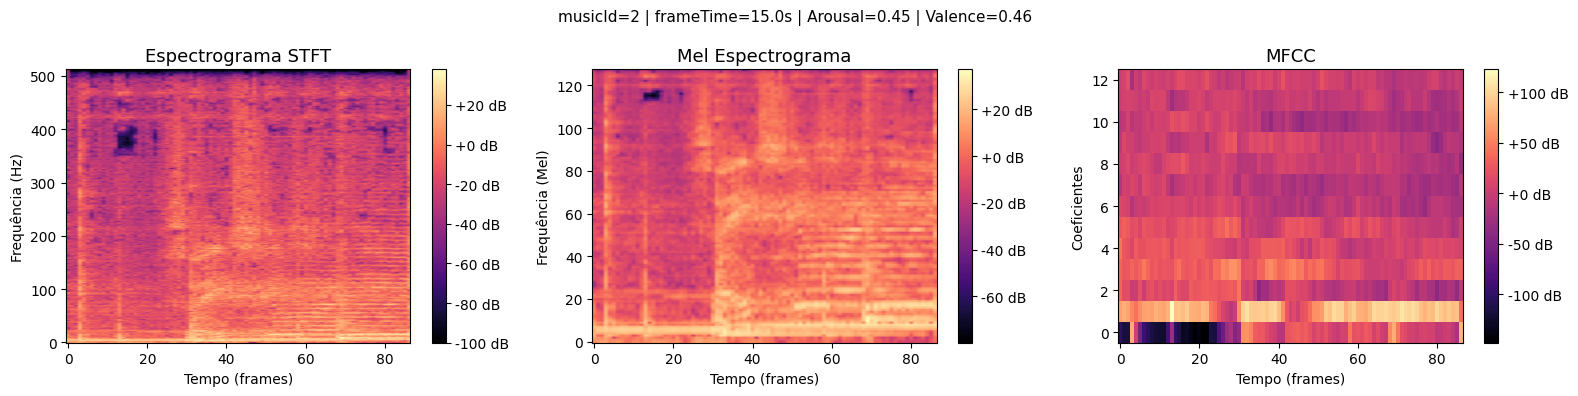

In [14]:
row = dataset.iloc[0]
music_id   = int(row['musicId'])
frame_time = float(row['frameTime'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

titulos = {
    "stft": "Espectrograma STFT",
    "mel":  "Mel Espectrograma",
    "mfcc": "MFCC",
}

ylabels = {
    "stft": "Frequência (Hz)",
    "mel":  "Frequência (Mel)",
    "mfcc": "Coeficientes",
}

for ax, modo in zip(axes, ["stft", "mel", "mfcc"]):
    feat = carregar_feature(music_id, frame_time, audio_map, modo)
    img  = feat.squeeze(0).numpy()

    im = ax.imshow(img, aspect="auto", origin="lower", cmap="magma")
    ax.set_title(titulos[modo], fontsize=13)
    ax.set_xlabel("Tempo (frames)")
    ax.set_ylabel(ylabels[modo])
    plt.colorbar(im, ax=ax, format="%+2.0f dB")

fig.suptitle(f"musicId={music_id} | frameTime={frame_time}s | "
             f"Arousal={row['Arousal(mean)']:.2f} | Valence={row['Valence(mean)']:.2f}",
             fontsize=11)
plt.tight_layout()
plt.show()

### **Verificação de GPU/CPU**

---
## Passo a Passo: Como Treinar as Redes

Este guia descreve todos os passos necessários para reproduzir o treinamento do projeto do zero.

---

### Pré-requisitos

```
pip install torch torchaudio librosa pandas numpy scikit-learn matplotlib seaborn scipy
```

**Estrutura de pastas esperada:**
```
projeto_mer/
├── data/
│   ├── deam/audio/          ← arquivos .mp3 do DEAM (1802 músicas)
│   └── dynamic_annotations.csv
├── data/processed/          ← criado automaticamente pelo preprocess.py
│   ├── mel/
│   ├── mfcc/
│   └── stft/
├── checkpoints/             ← criado automaticamente pelo train.py
├── dataset.py
├── model.py
├── train.py
└── preprocess.py
```

---

### Passo 1 — Pré-processamento (obrigatório, executar uma vez)

```bash
python preprocess.py --modo mel
python preprocess.py --modo mfcc
python preprocess.py --modo stft
```

Este passo lê cada música uma vez, extrai todos os frames e salva **1 arquivo `.pt` por música** em `data/processed/{modo}/`. O resultado são ~5.400 arquivos por modo (um por música), evitando I/O excessivo durante o treino.

**Sem este passo o treino será muito lento** (leria o áudio a cada batch).

---

### Passo 2 — Treino

```bash
python train.py --modo mel   --arch resnet18 --epochs 100
python train.py --modo mfcc  --arch resnet18 --epochs 100
python train.py --modo stft  --arch resnet18 --epochs 100
```

Ou executar os 3 de uma vez com o script batch:
```bash
run_all.bat
```

O treino executa **5-fold cross-validation** por música e salva os checkpoints em `checkpoints/`. Ao final gera `resultados_{arch}_{modo}_dinamico.json` com todas as métricas.

---

### Passo 3 — Análise Comparativa

Abrir e executar `benchmark.ipynb` para gerar os gráficos comparativos entre os 3 modos.

Para análises extras do TCC (baseline, Wilcoxon, scatter plots):
```bash
python analise_tcc.py
```

---

### Passo 4 — Predição em música nova

```bash
python predict.py --arquivo caminho/para/musica.mp3 --arch resnet18 --modo mel
```

---
## Explicação de Todos os Processos e Parâmetros

---

### 1. Dataset — DEAM

| Parâmetro | Valor | Descrição |
|---|---|---|
| Total de músicas | 1.802 | Faixas CC de 45s e música completa |
| frameTime | a cada 500ms | Intervalo entre anotações dinâmicas |
| Janela extraída | **4 segundos** | Áudio ao redor de cada frameTime |
| Sample rate | **22.050 Hz** | Taxa de amostragem padrão (librosa) |
| Labels | Arousal, Valence | Escala original [-1,1] → normalizada [0,1] |
| Escala normalizada | `(x + 1) / 2` | Compatível com saída Sigmoid da rede |

**Split dos dados:**
- 10% de músicas → conjunto de **teste fixo** (nunca visto durante treino)
- 90% restantes → **5-fold cross-validation** por música (não por frame, para evitar data leakage)
- Seed fixo `random_state=3` para reprodutibilidade

---

### 2. Pré-processamento dos Espectrogramas

Cada frame de áudio (janela de 4s = 88.200 amostras a 22.050 Hz) é convertido em:

| Representação | Parâmetros | Shape final |
|---|---|---|
| **STFT** | n_fft=1024, hop=512 | `(1, 513, 173)` |
| **MEL** | n_mels=128, n_fft=1024, hop=512 | `(1, 128, 173)` |
| **MFCC** | n_mfcc=13, n_fft=1024, hop=512 | `(1, 13, 173)` |

**Cache em disco:** os espectrogramas são pré-calculados uma única vez e salvos em `data/processed/{modo}/{musicId}.pt`. Cada arquivo `.pt` contém um dicionário com todos os frames daquela música, permitindo carregar tudo em RAM no início do treino.

**Normalização:** média e desvio padrão calculados no conjunto de treino (por fold) e aplicados em tempo de carregamento. Garante que cada canal tenha distribuição ~N(0,1) na entrada da rede.

---

### 3. Arquitetura — ResNet18

A ResNet18 pré-treinada no ImageNet é adaptada para espectrogramas:

- **Entrada:** adaptada de 3 canais (RGB) para 1 canal (espectrograma mono) — pesos inicializados pela média dos 3 canais originais
- **Camadas congeladas:** stem (conv1 + bn1) e layer1 — preservam detectores genéricos de baixo nível que transferem bem para espectrogramas
- **Camadas treináveis:** layer2, layer3, layer4 + nova cabeça de regressão
- **Cabeça:** `Flatten → Dropout(0.5) → Linear(512,128) → ReLU → Dropout(0.4) → Linear(128,2) → Sigmoid`
- **Saída:** 2 valores em [0,1] — Arousal e Valence

O `AdaptiveAvgPool2d` do ResNet garante que qualquer shape de frequência (MFCC=13, MEL=128, STFT=128) produza o mesmo vetor de 512 features antes da cabeça.

---

### 4. Função de Loss

Loss customizada combinando três componentes:

```
Loss = 0.5 × SmoothL1 + 0.25 × (1 - CCC_Arousal) + 0.25 × (1 - CCC_Valence)
```

- **SmoothL1**: erro absoluto suavizado, menos sensível a outliers que MSE
- **CCC (Concordance Correlation Coefficient)**: métrica padrão em MER — penaliza predições que erram não só a direção mas também a escala e o nível médio
- A combinação força o modelo a minimizar tanto o erro por amostra quanto a correlação global

---

### 5. Otimizador e Scheduler

| Parâmetro | Valor | Descrição |
|---|---|---|
| Otimizador | **AdamW** | Adam com weight decay desacoplado |
| LR (base) | `3e-4` | Learning rate para ResNet18 |
| LR (layer1) | `LR × 0.05 = 1.5e-5` | LR reduzido para camada parcialmente congelada |
| Weight decay | `1e-4` | Regularização L2 |
| Gradient clip | `max_norm=1.0` | Evita explosão de gradiente |

**Scheduler em duas fases:**
1. **Warmup linear** (5 épocas): LR sobe de 10% para 100% — evita que o modelo destrua os pesos pré-treinados no início
2. **Cosine Annealing** (restante): LR decai suavemente de LR até 1e-6, permitindo convergência fina

---

### 6. Estratégias de Regularização e Balanceamento

**Desbalanceamento de quadrantes** (Exaltado domina com 49%):

- **WeightedRandomSampler**: amostras de quadrantes raros são sorteadas mais frequentemente, garantindo que todos os quadrantes apareçam a cada época
- **Subsample por quadrante**: quadrantes dominantes têm step maior (Exaltado usa 1 a cada 4 frames); minoritários usam step menor (mais frames)

**Mixup assimétrico:** interpola pares de amostras com preferência para pares de quadrantes minoritários (prob=0.7), aumentando artificialmente a diversidade de exemplos raros.

**Augmentação no tempo de carregamento:** ruído gaussiano leve (`σ=0.01`) e time masking aleatório aplicados apenas no conjunto de treino.

---

### 7. 5-Fold Cross-Validation

O split é feito **por música** (não por frame):

- Cada fold tem ~325 músicas para treino e ~81 para validação
- Evita data leakage: frames da mesma música sempre ficam no mesmo subset
- O **melhor fold** (maior CCC médio na validação) é usado para avaliação no teste final
- Resultados reportados: médias e desvios padrão dos 5 folds + resultado no teste final

---

### 8. Early Stopping

| Parâmetro | Valor |
|---|---|
| Patience | **30 épocas** |
| Monitorado | `val_loss` |
| Épocas máximas | 100 |

Se a `val_loss` não melhorar por 30 épocas consecutivas, o treino encerra e restaura os pesos do melhor checkpoint salvo.

---

### 9. Mixed Precision (AMP BF16)

Em GPUs compatíveis (RTX série 30+), o treino usa **BFloat16** automaticamente:

- Forward e backward passam em BF16 — ~2× mais rápido, ~50% menos VRAM
- Optimizer step mantém pesos em FP32 para precisão numérica
- `GradScaler` gerencia o escalonamento do gradiente para evitar underflow

---

### 10. Métricas de Avaliação

| Métrica | Interpretação |
|---|---|
| **CCC** | Principal. Mede concordância em direção E escala. Padrão em MER. |
| **Pearson** | Mede correlação linear. Não penaliza offset sistemático. |
| **RMSE** | Erro quadrático médio. Penaliza erros grandes. |
| **MAE** | Erro absoluto médio. Mais robusto a outliers. |
| **R²** | Variância explicada. R²=0 significa que o modelo equivale à média. |
| **Acc / F1-macro** | Classificação nos 4 quadrantes de Russell. F1-macro penaliza desbalanceamento. |

In [15]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name())

2.12.0.dev20260327+cu128
12.8
True
NVIDIA GeForce RTX 5070
